# Monte Carlo Simulation — First Principles

This notebook explains **Monte Carlo simulation** as a general method,
then shows how it applies to option pricing.

## What is Monte Carlo Simulation?

Monte Carlo is a **numerical method** that uses random sampling to estimate quantities
that are difficult (or impossible) to compute analytically.

The idea is simple:
1. Define a random process that generates outcomes
2. Simulate many outcomes ("paths")
3. Average the results to get an estimate

By the **Law of Large Numbers**, this average converges to the true expected value
as the number of simulations increases.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#333355',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#333355',
    'figure.figsize': (10, 6),
    'font.size': 11,
})

np.random.seed(42)

---

## Example 1: Estimating π with Random Darts

Classic Monte Carlo: throw darts at a unit square containing a quarter-circle.

$$\pi \approx 4 \times \frac{\text{darts inside circle}}{\text{total darts}}$$

Estimated π = 3.147200
     True π = 3.141593
       Error = 0.005607


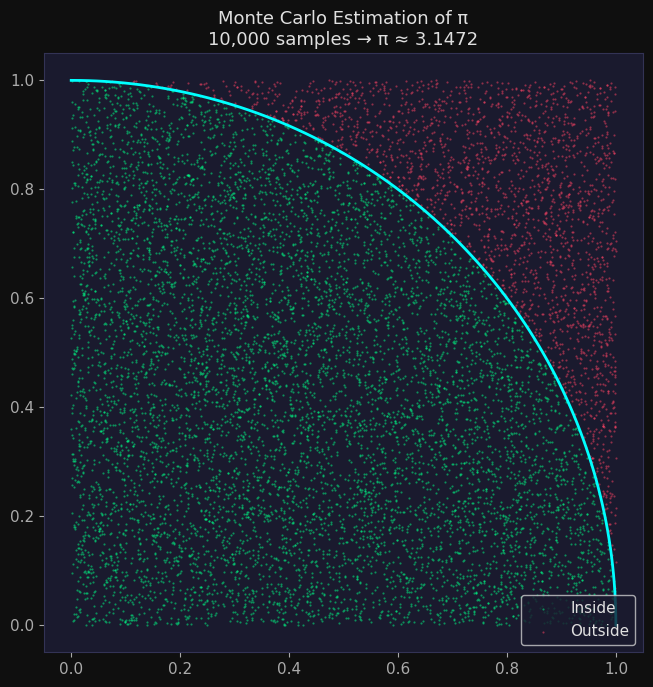

In [6]:
# Monte Carlo estimation of pi
n_samples = 10000

# Random points in the unit square
x = np.random.uniform(0, 1, n_samples)
y = np.random.uniform(0, 1, n_samples)

# Check if inside quarter-circle of radius 1
inside = (x**2 + y**2) <= 1.0

# Estimate pi
pi_estimate = 4.0 * np.sum(inside) / n_samples
print(f"Estimated π = {pi_estimate:.6f}")
print(f"     True π = {np.pi:.6f}")
print(f"       Error = {abs(pi_estimate - np.pi):.6f}")

# Visualize
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x[inside], y[inside], s=0.3, alpha=0.5, color='#00ff88', label='Inside')
ax.scatter(x[~inside], y[~inside], s=0.3, alpha=0.5, color='#ff4466', label='Outside')

# Draw the quarter circle
theta = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(theta), np.sin(theta), color='#00ffff', linewidth=2)

ax.set_aspect('equal')
ax.set_title(f'Monte Carlo Estimation of π\n{n_samples:,} samples → π ≈ {pi_estimate:.4f}', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## Example 2: Estimating an Integral

Monte Carlo integration: estimate $\int_0^1 e^{-x^2} dx$

The idea: $\int_a^b f(x) dx = (b-a) \cdot E[f(X)]$ where $X \sim \text{Uniform}(a,b)$

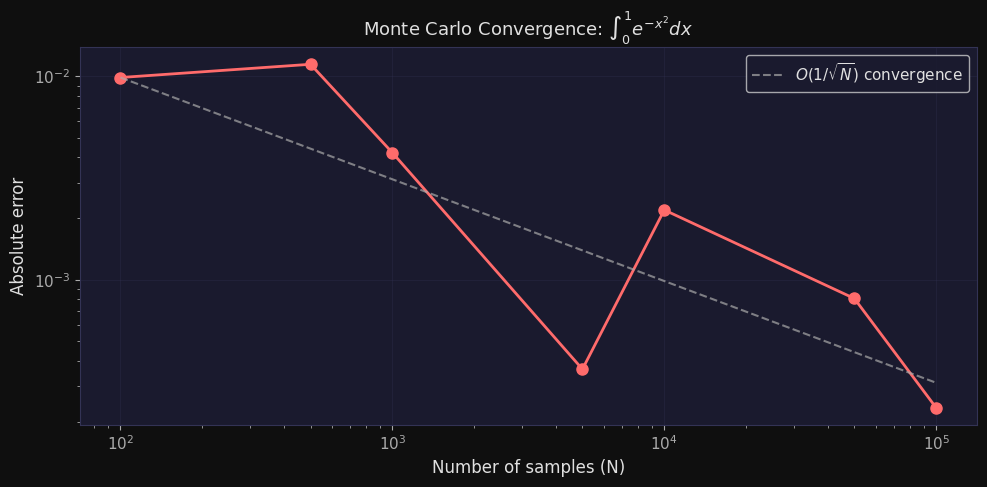

True value:    0.74682413
MC (100k):     0.74658936

Key insight: error decreases as O(1/√N) — need 4× more samples to halve the error


In [7]:
# Monte Carlo integration: E[e^(-X^2)] for X ~ Uniform(0,1)
n_samples_list = [100, 500, 1000, 5000, 10000, 50000, 100000]
estimates = []

from scipy.integrate import quad
true_value, _ = quad(lambda x: np.exp(-x**2), 0, 1)

for n in n_samples_list:
    x = np.random.uniform(0, 1, n)
    est = np.mean(np.exp(-x**2))
    estimates.append(est)

# Convergence plot
fig, ax = plt.subplots(figsize=(10, 5))
errors = [abs(e - true_value) for e in estimates]

ax.loglog(n_samples_list, errors, 'o-', color='#ff6b6b', linewidth=2, markersize=8)

# Theoretical O(1/sqrt(N)) convergence
ref = [errors[0] * np.sqrt(n_samples_list[0] / n) for n in n_samples_list]
ax.loglog(n_samples_list, ref, '--', color='#aaaaaa', alpha=0.7, label=r'$O(1/\sqrt{N})$ convergence')

ax.set_xlabel('Number of samples (N)', fontsize=12)
ax.set_ylabel('Absolute error', fontsize=12)
ax.set_title(r'Monte Carlo Convergence: $\int_0^1 e^{-x^2}dx$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True value:    {true_value:.8f}")
print(f"MC (100k):     {estimates[-1]:.8f}")
print(f"\nKey insight: error decreases as O(1/√N) — need 4× more samples to halve the error")

---

## Example 3: Monte Carlo for Option Pricing

### Single-asset European Call (Black-Scholes)

Under the risk-neutral measure, a stock follows **Geometric Brownian Motion (GBM)**:

$$S(T) = S(0) \cdot \exp\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T} \cdot Z\right]$$

where $Z \sim \mathcal{N}(0,1)$.

The option price is:
$$C = e^{-rT} \cdot E\left[\max(S(T) - K, 0)\right]$$

We compare the MC result with the **exact Black-Scholes formula**.

In [8]:
# Parameters
S0 = 100      # Spot price
K = 105       # Strike price (slightly OTM)
T = 0.5       # 6 months
r = 0.05      # Risk-free rate
sigma = 0.25  # Volatility
n_paths = 500_000

# ──── Black-Scholes exact price ────────────────────────────────────
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
BS_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# ──── Monte Carlo price ──────────────────────────────────────────
Z = np.random.standard_normal(n_paths)
S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoffs = np.maximum(S_T - K, 0)
MC_price = np.exp(-r*T) * np.mean(payoffs)
MC_std = np.exp(-r*T) * np.std(payoffs) / np.sqrt(n_paths)

print(f"Black-Scholes price: ${BS_price:.4f}")
print(f"Monte Carlo price:   ${MC_price:.4f} ± ${MC_std:.4f}")
print(f"Error:               ${abs(MC_price - BS_price):.4f}")

Black-Scholes price: $5.9885
Monte Carlo price:   $5.9833 ± $0.0151
Error:               $0.0052


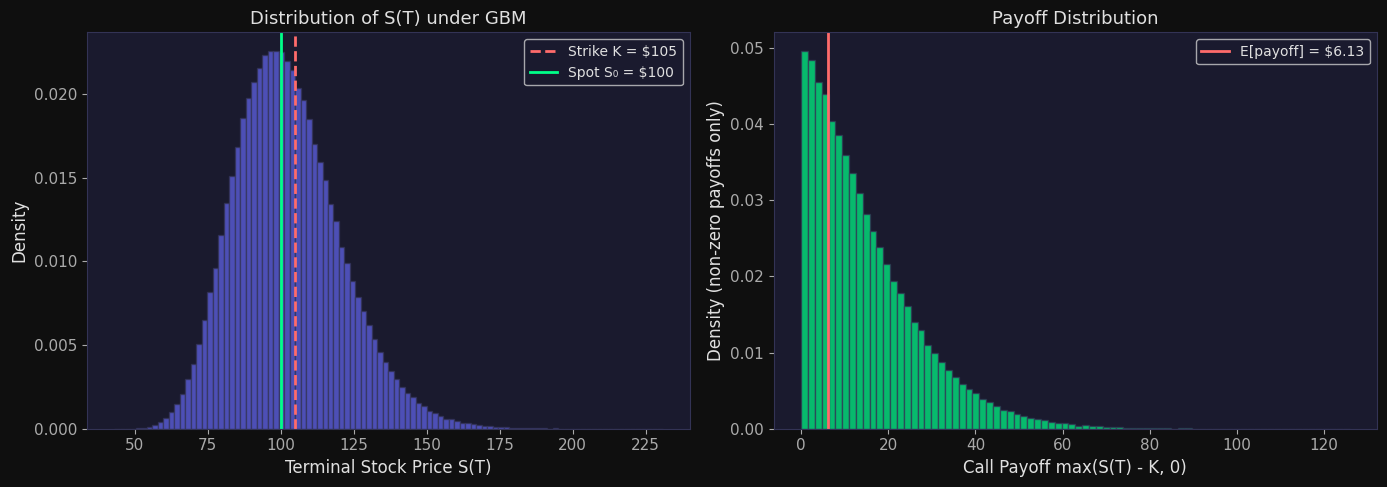


41.1% of paths ended in-the-money


In [9]:
# Visualize the terminal price distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Terminal price distribution
ax1.hist(S_T, bins=100, density=True, color='#6366f1', alpha=0.7, edgecolor='#333355')
ax1.axvline(K, color='#ff6b6b', linewidth=2, linestyle='--', label=f'Strike K = ${K}')
ax1.axvline(S0, color='#00ff88', linewidth=2, linestyle='-', label=f'Spot S₀ = ${S0}')
ax1.set_xlabel('Terminal Stock Price S(T)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of S(T) under GBM', fontsize=13)
ax1.legend(fontsize=10)

# Right: Payoff distribution
nonzero_payoffs = payoffs[payoffs > 0]
ax2.hist(nonzero_payoffs, bins=80, density=True, color='#00ff88', alpha=0.7, edgecolor='#333355')
ax2.axvline(np.mean(payoffs), color='#ff6b6b', linewidth=2, label=f'E[payoff] = ${np.mean(payoffs):.2f}')
ax2.set_xlabel('Call Payoff max(S(T) - K, 0)', fontsize=12)
ax2.set_ylabel('Density (non-zero payoffs only)', fontsize=12)
ax2.set_title('Payoff Distribution', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

itm_pct = 100 * np.mean(payoffs > 0)
print(f"\n{itm_pct:.1f}% of paths ended in-the-money")

---

## Why Monte Carlo for Basket Options?

For a **single-asset** European call, we don't need Monte Carlo — Black-Scholes gives
an exact closed-form formula.

But for a **basket call** on two correlated stocks:

$$\text{Payoff} = \max(w_1 \cdot S_1(T) + w_2 \cdot S_2(T) - K, \; 0)$$

The sum $w_1 S_1 + w_2 S_2$ of two correlated lognormal variables is **NOT lognormal**.
This breaks the Black-Scholes framework, and **no closed-form formula exists**.

Monte Carlo handles this naturally: we simulate BOTH stocks simultaneously using
**correlated random numbers** (via Cholesky decomposition).

In [10]:
# ──── Basket Call Monte Carlo ──────────────────────────────────────

# Parameters
S1_0, S2_0 = 130.0, 170.0     # Spot prices
sigma1, sigma2 = 0.50, 0.30   # Volatilities
rho = 0.6                      # Correlation
w1, w2 = 0.5, 0.5             # Equal weights
K_basket = w1*S1_0 + w2*S2_0  # ATM strike
T_basket = 0.25                # 3 months
r_basket = 0.05
n_paths_basket = 200_000

print(f"Basket ATM strike: K = {w1}×{S1_0} + {w2}×{S2_0} = ${K_basket:.2f}")

# Generate correlated normals via Cholesky decomposition
Z1 = np.random.standard_normal(n_paths_basket)
Z2 = np.random.standard_normal(n_paths_basket)

# Cholesky: W2 = rho*Z1 + sqrt(1-rho^2)*Z2
W1 = Z1
W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

# Check: correlation of W1, W2 should be close to rho
print(f"Empirical correlation: {np.corrcoef(W1, W2)[0,1]:.4f} (target: {rho})")

# Simulate terminal prices (GBM)
S1_T = S1_0 * np.exp((r_basket - 0.5*sigma1**2)*T_basket + sigma1*np.sqrt(T_basket)*W1)
S2_T = S2_0 * np.exp((r_basket - 0.5*sigma2**2)*T_basket + sigma2*np.sqrt(T_basket)*W2)

# Basket payoff
basket_T = w1*S1_T + w2*S2_T
basket_payoffs = np.maximum(basket_T - K_basket, 0)

# Price
basket_price = np.exp(-r_basket*T_basket) * np.mean(basket_payoffs)
basket_std = np.exp(-r_basket*T_basket) * np.std(basket_payoffs) / np.sqrt(n_paths_basket)

print(f"\nBasket Call Price: ${basket_price:.4f} ± ${basket_std:.4f}")

Basket ATM strike: K = 0.5×130.0 + 0.5×170.0 = $150.00
Empirical correlation: 0.5985 (target: 0.6)

Basket Call Price: $11.1715 ± $0.0393


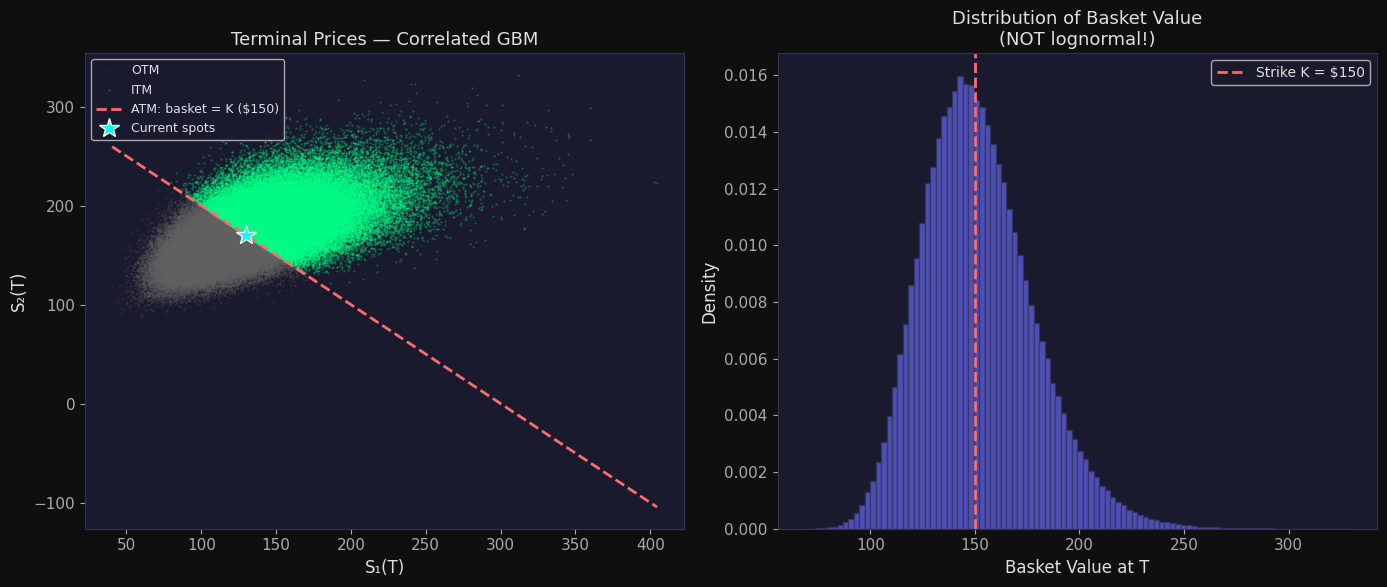


This is why Monte Carlo is necessary:
The basket distribution is NOT lognormal → no closed-form pricing formula.
We must simulate paths and average payoffs.


In [11]:
# Visualize: joint terminal distribution of S1(T), S2(T)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter plot of terminal prices
itm = basket_payoffs > 0
ax1.scatter(S1_T[~itm], S2_T[~itm], s=0.3, alpha=0.2, color='#666666', label='OTM')
ax1.scatter(S1_T[itm], S2_T[itm], s=0.3, alpha=0.3, color='#00ff88', label='ITM')

# ATM line: w1*S1 + w2*S2 = K
s1_line = np.linspace(S1_T.min(), S1_T.max(), 100)
s2_line = (K_basket - w1*s1_line) / w2
ax1.plot(s1_line, s2_line, '--', color='#ff6b6b', linewidth=2, label=f'ATM: basket = K (${K_basket:.0f})')
ax1.plot(S1_0, S2_0, '*', color='#00ffff', markersize=15, markeredgecolor='white', label='Current spots')

ax1.set_xlabel('S₁(T)', fontsize=12)
ax1.set_ylabel('S₂(T)', fontsize=12)
ax1.set_title('Terminal Prices — Correlated GBM', fontsize=13)
ax1.legend(fontsize=9, loc='upper left')

# Right: basket value distribution
ax2.hist(basket_T, bins=100, density=True, color='#6366f1', alpha=0.7, edgecolor='#333355')
ax2.axvline(K_basket, color='#ff6b6b', linewidth=2, linestyle='--', label=f'Strike K = ${K_basket:.0f}')
ax2.set_xlabel('Basket Value at T', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of Basket Value\n(NOT lognormal!)', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nThis is why Monte Carlo is necessary:")
print(f"The basket distribution is NOT lognormal → no closed-form pricing formula.")
print(f"We must simulate paths and average payoffs.")

---

## Variance Reduction: Antithetic Variates

Standard Monte Carlo converges as $O(1/\sqrt{N})$ — slow!

**Antithetic variates** is a simple trick: for each random sample $Z$, also use $-Z$.
Since $f(Z)$ and $f(-Z)$ are negatively correlated, their average has lower variance.

$$\hat{C} = \frac{1}{2N} \sum_{i=1}^{N} \left[f(Z_i) + f(-Z_i)\right]$$

This effectively doubles the number of paths for free.

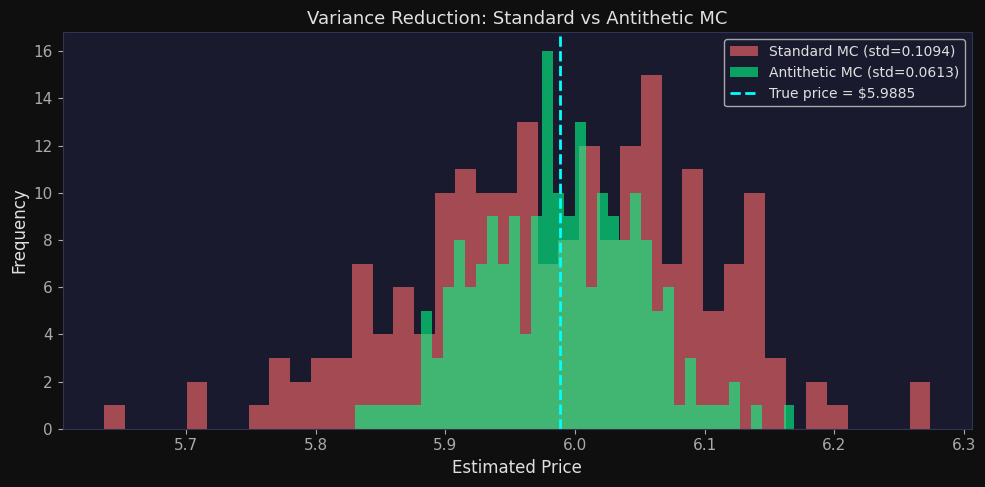


Variance reduction: 68.6%
Antithetic variates reduce noise significantly → more accurate for same compute.


In [12]:
# Compare: standard MC vs. antithetic variates
n_trials = 200
n_paths_trial = 10_000

prices_standard = []
prices_antithetic = []

for _ in range(n_trials):
    Z = np.random.standard_normal(n_paths_trial)
    
    # Standard MC
    S_T_std = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoff_std = np.maximum(S_T_std - K, 0)
    prices_standard.append(np.exp(-r*T) * np.mean(payoff_std))
    
    # Antithetic MC (use both Z and -Z)
    Z_anti = np.concatenate([Z, -Z])
    S_T_anti = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_anti)
    payoff_anti = np.maximum(S_T_anti - K, 0)
    prices_antithetic.append(np.exp(-r*T) * np.mean(payoff_anti))

# Compare
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(prices_standard, bins=40, alpha=0.6, color='#ff6b6b', label=f'Standard MC (std={np.std(prices_standard):.4f})')
ax.hist(prices_antithetic, bins=40, alpha=0.6, color='#00ff88', label=f'Antithetic MC (std={np.std(prices_antithetic):.4f})')
ax.axvline(BS_price, color='#00ffff', linewidth=2, linestyle='--', label=f'True price = ${BS_price:.4f}')
ax.set_xlabel('Estimated Price', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Variance Reduction: Standard vs Antithetic MC', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

reduction = (1 - np.var(prices_antithetic) / np.var(prices_standard)) * 100
print(f"\nVariance reduction: {reduction:.1f}%")
print(f"Antithetic variates reduce noise significantly → more accurate for same compute.")

---

## Key Takeaways

| Concept | Key Idea |
|---------|----------|
| **Monte Carlo** | Estimate expectations by averaging random samples |
| **Convergence** | Error decreases as $O(1/\sqrt{N})$ — need 4× samples for 2× accuracy |
| **GBM** | Stock prices modeled as $S(T) = S(0) \exp[(r - \sigma^2/2)T + \sigma\sqrt{T}Z]$ |
| **Cholesky** | Transform independent normals into correlated normals: $W_2 = \rho Z_1 + \sqrt{1-\rho^2} Z_2$ |
| **Antithetic** | Use both $Z$ and $-Z$ to reduce variance for free |
| **Basket options** | Sum of lognormals is NOT lognormal → no exact formula → MC required |

